# Inspección de bajo nivel — arrays del detector PET
Visualiza los arrays crudos: psipm.tsv, eventos binarios, matrices densas.

In [ ]:
import struct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display, clear_output
from pathlib import Path

# ── rutas ──────────────────────────────────────────────────────
DATA_ROOT  = r'E:\Datos TFM'
PSIPM_PATH = r'E:\Datos TFM\psipm.tsv'

INACTIVE = {1, 16, 18}
ACTIVE   = sorted(set(range(64)) - INACTIVE)
ICH2IDX  = {ich: i for i, ich in enumerate(ACTIVE)}
IDX2ICH  = {i: ich for ich, i in ICH2IDX.items()}
N        = len(ACTIVE)   # 61
print(f'Canales activos: {N}  |  inactivos: {sorted(INACTIVE)}')

Canales activos: 61  |  inactivos: [1, 16, 18]


---
## 1 · psipm.tsv — el array de posiciones

In [ ]:
# ── carga robusta del tsv ──────────────────────────────────────
for sep in ['\t', ',', ' ', ';']:
    df = pd.read_csv(PSIPM_PATH, sep=sep, header=None)
    if len(df.columns) >= 3: break

df_raw=df.copy()



#SOLIDO IMPORT; EN NUESTRO CASO NO ES NECESARIO PUES EL PSIMP VIENE CLEAN
df.columns = [c.strip().lower() for c in df.columns]
cols = list(df.columns)
ich_c = next((c for c in cols if c.replace('_','') in ('ich','channel','ch','id','n')), cols[0])
x_c   = next((c for c in cols if c.startswith('x')), cols[1])
y_c   = next((c for c in cols if c.startswith('y')), cols[2])
df = df.rename(columns={ich_c:'ich', x_c:'xsipm', y_c:'ysipm'})
df['ich'] = pd.to_numeric(df['ich'], errors='coerce').astype('Int64')
df = df.dropna(subset=['ich'])
df = df[df['ich'].isin(ACTIVE)].sort_values('ich').reset_index(drop=True)

# arrays numpy
ICH_ARR  = df['ich'].values.astype(int)       # shape (61,)
X_SIPM   = df['xsipm'].values.astype(float)   # shape (61,)
Y_SIPM   = df['ysipm'].values.astype(float)   # shape (61,)

print(f'Shape ICH_ARR : {ICH_ARR.shape}   dtype={ICH_ARR.dtype}')
print(f'Shape X_SIPM  : {X_SIPM.shape}    dtype={X_SIPM.dtype}')
print(f'Shape Y_SIPM  : {Y_SIPM.shape}    dtype={Y_SIPM.dtype}')
print(f'X rango: [{X_SIPM.min():.3f}, {X_SIPM.max():.3f}]')
print(f'Y rango: [{Y_SIPM.min():.3f}, {Y_SIPM.max():.3f}]')
print()
print(df.to_string(index=False))

Shape ICH_ARR : (60,)   dtype=int64
Shape X_SIPM  : (60,)    dtype=float64
Shape Y_SIPM  : (60,)    dtype=float64
X rango: [-13.000, 13.000]
Y rango: [-15.000, 15.000]

 ich  xsipm  ysipm
   0   3.25  -1.88
   2  -0.00   7.50
   3   6.50  -7.50
   4  -0.00 -15.00
   5   9.75  -1.88
   6  -0.00   3.75
   7   9.75  -5.63
   8  13.00  -3.75
   9   3.25  -9.38
  10   9.75  -9.38
  11  -0.00  -3.75
  12   6.50  -3.75
  13  -0.00  -0.00
  14  13.00  -7.50
  15  13.00  -0.00
  17  -3.25  -5.63
  19  -6.50  -7.50
  20  -3.25  13.13
  21  -3.25 -13.13
  22  -3.25  -9.38
  23  -0.00  -7.50
  24  -0.00 -11.25
  25   3.25 -13.13
  26  -3.25   9.38
  27  -0.00  15.00
  28  -3.25   5.63
  29  -3.25   1.88
  30  -0.00  11.25
  31  -3.25  -1.88
  32  -6.50 -11.25
  33  -6.50  -3.75
  34  -9.75  -5.63
  35  -9.75  -9.38
  36  -6.50  -0.00
  38   6.50 -11.25
  39 -13.00  -3.75
  40  -6.50  11.25
  41  -9.75  -1.88
  42  -6.50   3.75
  43  -9.75   1.88
  44  -6.50   7.50
  45 -13.00  -0.00
  46  -9.75   

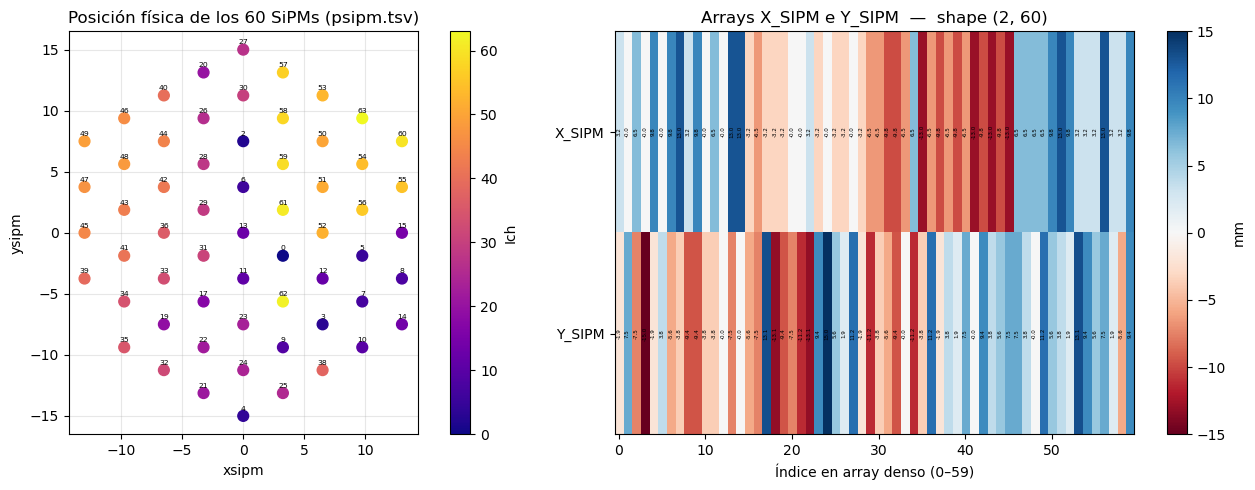

SiPMs cargados del psipm.tsv: 60  (esperados: 61)
Canales ausentes en el tsv: [37]


In [ ]:
# ── scatter de posiciones + etiquetas Ich ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# scatter XY
ax = axes[0]
ax.scatter(X_SIPM, Y_SIPM, s=60, c=ICH_ARR, cmap='plasma', zorder=3)
for i, (x, y, ich) in enumerate(zip(X_SIPM, Y_SIPM, ICH_ARR)):
    ax.text(x, y + 0.35, str(ich), ha='center', va='bottom', fontsize=5.5)
ax.set_title(f'Posición física de los {len(ICH_ARR)} SiPMs (psipm.tsv)')
ax.set_xlabel('xsipm'); ax.set_ylabel('ysipm')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.colorbar(ax.collections[0], ax=ax, label='Ich')

# arrays en bruto como heatmap 1D
ax2 = axes[1]
n_loaded = len(X_SIPM)   # usa la longitud real, no N=61
data_2d = np.vstack([X_SIPM, Y_SIPM])   # (2, n_loaded)
im = ax2.imshow(data_2d, aspect='auto', cmap='RdBu',
                extent=[-0.5, n_loaded - 0.5, -0.5, 1.5])
ax2.set_yticks([0, 1]); ax2.set_yticklabels(['Y_SIPM', 'X_SIPM'])
ax2.set_xlabel(f'Índice en array denso (0–{n_loaded - 1})')
ax2.set_title(f'Arrays X_SIPM e Y_SIPM  —  shape (2, {n_loaded})')
plt.colorbar(im, ax=ax2, label='mm')
for j in range(n_loaded):   # ← iteramos sobre n_loaded, no N
    ax2.text(j, 1, f'{X_SIPM[j]:.1f}', ha='center', va='center',
             fontsize=4, rotation=90, color='k')
    ax2.text(j, 0, f'{Y_SIPM[j]:.1f}', ha='center', va='center',
             fontsize=4, rotation=90, color='k')
plt.tight_layout(); plt.show()

print(f'SiPMs cargados del psipm.tsv: {n_loaded}  (esperados: 61)')
if n_loaded != 61:
    missing = sorted(set(ACTIVE) - set(ICH_ARR))
    print(f'Canales ausentes en el tsv: {missing}')

---
## 2 · Lectura del binario — inspección byte a byte

In [ ]:
def read_raw_events(path, max_events=5000):
    """Devuelve lista de dicts con 'nint', 'charges', 'channels' (sin densificar)."""
    events = []
    with open(path, 'rb') as f:
        while len(events) < max_events:
            b = f.read(1)
            if not b: break
            nint = struct.unpack('B', b)[0]
            if nint == 0: continue
            charges, channels = [], []
            ok = True
            for _ in range(nint):
                rb, ib = f.read(4), f.read(4)
                if len(rb) < 4 or len(ib) < 4: ok = False; break
                charges.append(struct.unpack('<f', rb)[0])
                channels.append(struct.unpack('<i', ib)[0])
            if ok:
                events.append({'nint': nint,
                               'charges':  np.array(charges,  dtype=np.float32),
                               'channels': np.array(channels, dtype=np.int32)})
    return events

def densify(events):
    """Convierte lista de eventos → matriz densa (N_events, 61)."""
    X = np.zeros((len(events), N), dtype=np.float32)
    for i, ev in enumerate(events):
        for rch, ich in zip(ev['charges'], ev['channels']):
            if ich in ICH2IDX:
                X[i, ICH2IDX[ich]] = rch
    return X

def calc_positions(X, X_SIPM, Y_SIPM):
    """
    X shape: (N, 61)
    X_SIPM, Y_SIPM shape: (61,) — deben estar ordenados igual que las
    columnas de X, es decir por ACTIVE_CH ascendente (que es como
    sort_values('ich') los deja).
    """
    # Doble comprobación del alineamiento — imprime las primeras 5 filas
    # para que puedas verificar visualmente que Ich y coordenada coinciden
    print("Verificación de alineamiento (primeras 5):")
    for i in range(5):
        print(f"  col {i} → Ich={ACTIVE[i]}  x={X_SIPM[i]:.2f}  y={Y_SIPM[i]:.2f}")

    r2  = X ** 2
    rt  = r2.sum(axis=1, keepdims=True).clip(1e-9)
    px  = (r2 * X_SIPM).sum(axis=1) / rt[:, 0]
    py  = (r2 * Y_SIPM).sum(axis=1) / rt[:, 0]
    return px, py
print('Funciones listas')

Funciones listas


In [ ]:
# ── selecciona un archivo Good y uno Bad ───────────────────────
root = Path(DATA_ROOT)
good_files = sorted((root/'Good'/'Good').glob('datas*.dat'))
bad_files  = sorted((root/'Bad'/'Bad').glob('datas*.dat'))

print(f'Good: {[f.name for f in good_files]}')
print(f'Bad:  {[f.name for f in bad_files]}')

# carga 5000 eventos de cada uno
raw_good = read_raw_events(good_files[0], max_events=5000)
raw_bad  = read_raw_events(bad_files[0],  max_events=5000)
print(f'\nEventos good: {len(raw_good)}   |   bad: {len(raw_bad)}')

Good: ['datas002.dat', 'datas003.dat', 'datas004.dat', 'datas006.dat', 'datas007.dat', 'datas011.dat', 'datas012.dat', 'datas013.dat', 'datas014.dat', 'datas015.dat', 'datas018.dat', 'datas019.dat', 'datas020.dat', 'datas021.dat', 'datas022.dat', 'datas023.dat', 'datas026.dat', 'datas027.dat', 'datas030.dat', 'datas031.dat', 'datas033.dat', 'datas035.dat', 'datas036.dat', 'datas037.dat', 'datas038.dat', 'datas039.dat', 'datas040.dat', 'datas043.dat', 'datas044.dat', 'datas045.dat', 'datas047.dat', 'datas048.dat', 'datas049.dat', 'datas052.dat', 'datas054.dat', 'datas055.dat', 'datas056.dat', 'datas057.dat', 'datas058.dat', 'datas062.dat', 'datas063.dat', 'datas064.dat', 'datas066.dat', 'datas067.dat', 'datas069.dat', 'datas071.dat', 'datas073.dat', 'datas075.dat', 'datas076.dat', 'datas077.dat', 'datas080.dat', 'datas081.dat', 'datas082.dat', 'datas083.dat', 'datas085.dat', 'datas086.dat', 'datas088.dat', 'datas090.dat', 'datas091.dat', 'datas092.dat', 'datas094.dat', 'datas095.dat', '

In [ ]:
# ── inspección de los primeros 5 eventos (estructura raw) ──────
print('=== Primeros 5 eventos (raw) ===\n')
for i, ev in enumerate(raw_good[:5]):
    print(f'Evento {i}:')
    print(f'  nint     = {ev["nint"]}')
    print(f'  channels = {ev["channels"]}   shape={ev["channels"].shape}  dtype={ev["channels"].dtype}')
    print(f'  charges  = {np.round(ev["charges"], 1)}   shape={ev["charges"].shape}  dtype={ev["charges"].dtype}')
    rcht = ev['charges'].sum()
    print(f'  RchT     = {rcht:.1f}   (suma de todas las cargas)')
    print()

=== Primeros 5 eventos (raw) ===

Evento 0:
  nint     = 19
  channels = [24 23  9 17 22 62 11 19  4 21 36  3 33  6  0 31 32 12 25]   shape=(19,)  dtype=int32
  charges  = [ 2.9  2.9  2.3  2.   1.9  1.7  1.4  1.1  0.7  0.6  0.5  0.5  0.4  0.3
  0.3  0.2  0.1 -0.3 -0.7]   shape=(19,)  dtype=float32
  RchT     = 18.7   (suma de todas las cargas)

Evento 1:
  nint     = 40
  channels = [26 30  2 44 40 28 20 48  6 58 54 56 55 51 29 60 11  0 42 50 53 61 62 36
 52 27 59 13 31 33 57 17  5 15 41 46 63 12 43 49]   shape=(40,)  dtype=int32
  charges  = [ 6.8  5.   4.2  4.1  3.9  3.6  2.9  2.5  2.3  2.1  1.9  1.8  1.8  1.7
  1.7  1.5  1.3  1.1  1.   1.   0.9  0.8  0.8  0.7  0.6  0.5  0.4  0.3
  0.  -0.1 -0.1 -0.2 -0.3 -0.4 -0.7 -0.7 -0.7 -0.8 -0.9 -1.7]   shape=(40,)  dtype=float32
  RchT     = 50.5   (suma de todas las cargas)

Evento 2:
  nint     = 21
  channels = [32 22 19 23 17 24 35 21 62 11  9 34  0 36 33  4 31  3 13 25 12]   shape=(21,)  dtype=int32
  charges  = [ 6.6  5.2  3.7  3.4  2.6 

---
## 3 · Matriz densa — shape (N_eventos, 61)

In [ ]:
Xg = densify(raw_good)   # (5000, 61)
Xb = densify(raw_bad)

print('=== Matriz densa Good ===')
print(f'  shape  : {Xg.shape}')
print(f'  dtype  : {Xg.dtype}')
print(f'  min    : {Xg.min():.4f}')
print(f'  max    : {Xg.max():.4f}')
print(f'  media  : {Xg.mean():.4f}')
print(f'  % ceros: {(Xg == 0).mean()*100:.1f}%  (canales que no dispararon)')
print()
print('=== Primeros 3 eventos como arrays (fila = evento, col = canal denso) ===')
print(np.round(Xg[:3], 1))

=== Matriz densa Good ===
  shape  : (5000, 61)
  dtype  : float32
  min    : -2.1042
  max    : 26.7071
  media  : 0.5220
  % ceros: 65.8%  (canales que no dispararon)

=== Primeros 3 eventos como arrays (fila = evento, col = canal denso) ===
[[ 0.3  0.   0.5  0.7  0.   0.3  0.   0.   2.3  0.   1.4 -0.3  0.   0.
   0.   2.   1.1  0.   0.6  1.9  2.9  2.9 -0.7  0.   0.   0.   0.   0.
   0.2  0.1  0.4  0.   0.   0.5  0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   1.7  0. ]
 [ 1.1  4.2  0.   0.  -0.3  2.3  0.   0.   0.   0.   1.3 -0.8  0.3  0.
  -0.4 -0.2  0.   2.9  0.   0.   0.   0.   0.   6.8  0.5  3.6  1.7  5.
   0.   0.  -0.1  0.   0.   0.7  0.   0.   0.   3.9 -0.7  1.  -0.9  4.1
   0.  -0.7  0.   2.5 -1.7  1.   1.7  0.6  0.9  1.9  1.8  1.8 -0.1  2.1
   0.4  1.5  0.8  0.8 -0.7]
 [ 0.9  0.   0.6  0.7  0.   0.   0.   0.   1.3  0.   1.5 -1.   0.1  0.
   0.   2.6  3.7  0.   1.5  5.2  3.4  1.6 -0.8  0.   0.   0

C:\Users\Miguel\AppData\Local\Temp\ipykernel_12136\1511591942.py:6: RuntimeWarning: invalid value encountered in log1p
  im = ax.imshow(np.log1p(X[:50]), aspect='auto', cmap='plasma',
C:\Users\Miguel\AppData\Local\Temp\ipykernel_12136\1511591942.py:6: RuntimeWarning: invalid value encountered in log1p
  im = ax.imshow(np.log1p(X[:50]), aspect='auto', cmap='plasma',


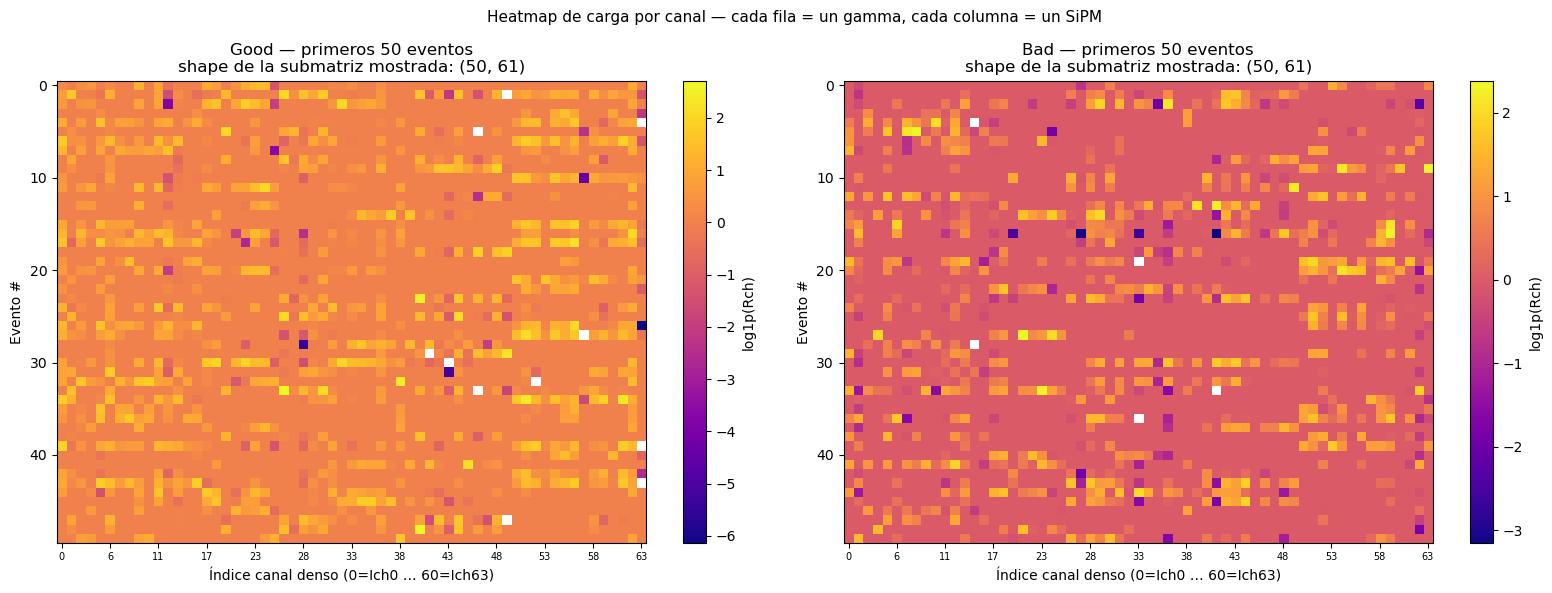

In [ ]:
# ── heatmap de los primeros 50 eventos ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X, label in [(axes[0], Xg, 'Good'), (axes[1], Xb, 'Bad')]:
    # log1p para ver canales débiles
    im = ax.imshow(np.log1p(X[:50]), aspect='auto', cmap='plasma',
                   interpolation='nearest')
    ax.set_title(f'{label} — primeros 50 eventos\nshape de la submatriz mostrada: (50, 61)')
    ax.set_xlabel('Índice canal denso (0=Ich0 … 60=Ich63)')
    ax.set_ylabel('Evento #')
    plt.colorbar(im, ax=ax, label='log1p(Rch)')
    # marcar los índices de Ich cada 5
    ticks = list(range(0, N, 5))
    ax.set_xticks(ticks)
    ax.set_xticklabels([IDX2ICH[t] for t in ticks], fontsize=7)

plt.suptitle('Heatmap de carga por canal — cada fila = un gamma, cada columna = un SiPM',
             fontsize=11)
plt.tight_layout(); plt.show()

---
## 4 · Estadísticas por canal — media y % de actividad

In [ ]:
mean_g = Xg.mean(axis=0)          # (61,)  carga media por canal
mean_b = Xb.mean(axis=0)
act_g  = (Xg > 0).mean(axis=0)    # (61,)  fracción de eventos donde disparó
act_b  = (Xb > 0).mean(axis=0)

print(f'mean_g shape: {mean_g.shape}   act_g shape: {act_g.shape}')
print()
print('Top 5 canales más activos (Good):')
top5 = np.argsort(mean_g)[-5:][::-1]
for idx in top5:
    print(f'  Idx denso={idx:2d}  Ich={IDX2ICH[idx]:2d}  '
          f'media={mean_g[idx]:.1f}  activo={act_g[idx]*100:.1f}%')

print()
print('Canales con actividad <1% en Bad (posibles averiados):')
dead = np.where(act_b < 0.01)[0]
for idx in dead:
    print(f'  Idx denso={idx:2d}  Ich={IDX2ICH[idx]:2d}  '
          f'actividad={act_b[idx]*100:.3f}%  (vs Good: {act_g[idx]*100:.1f}%)')

mean_g shape: (61,)   act_g shape: (61,)

Top 5 canales más activos (Good):
  Idx denso=59  Ich=62  media=1.2  activo=53.6%
  Idx denso=10  Ich=11  media=1.2  activo=46.9%
  Idx denso= 0  Ich= 0  media=1.1  activo=58.7%
  Idx denso=33  Ich=36  media=1.0  activo=54.2%
  Idx denso= 5  Ich= 6  media=1.0  activo=61.7%

Canales con actividad <1% en Bad (posibles averiados):


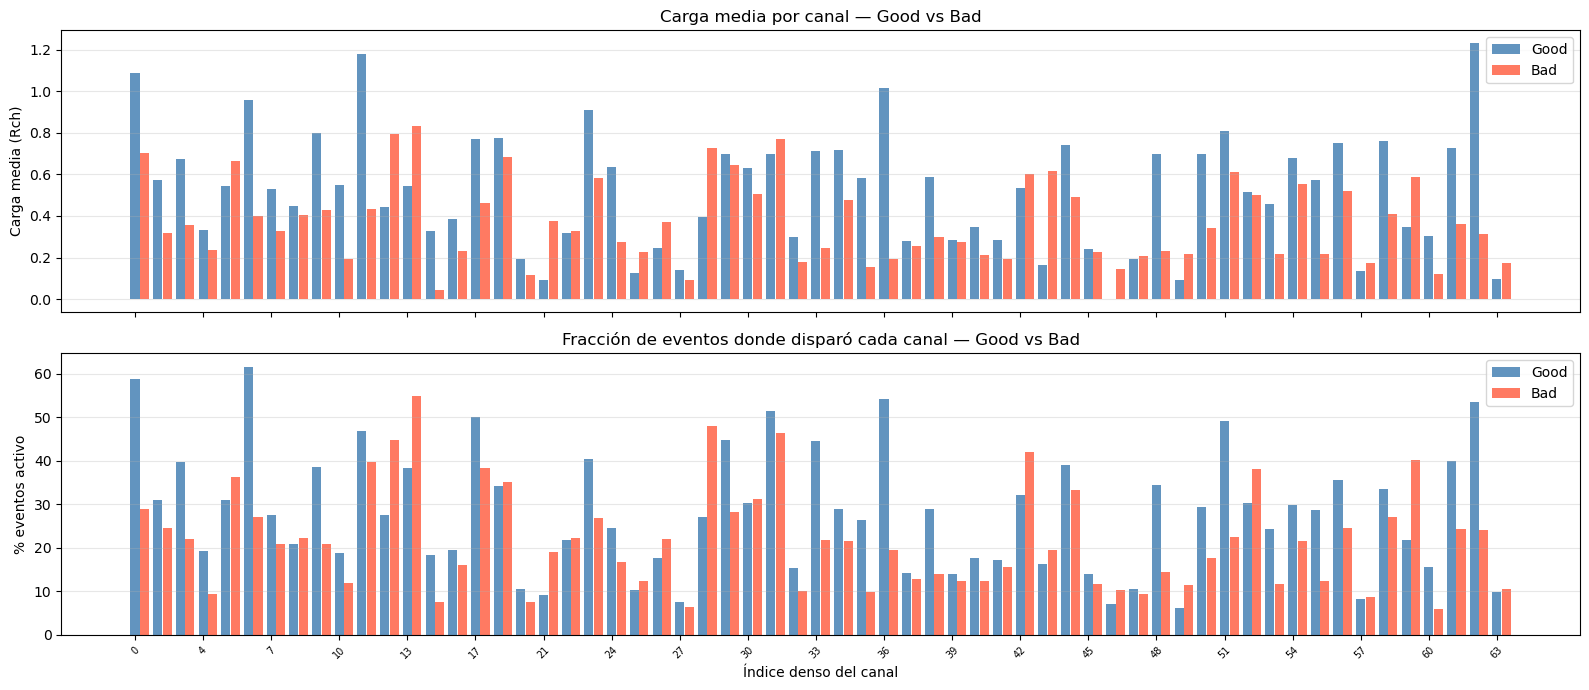


Vector diferencia |Good - Bad|  shape=(61,)
  max diff: canal idx=59  Ich=62  Δ=0.92


In [ ]:
# ── barplot comparativo Good vs Bad por canal ─────────────────
x = np.arange(N)
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].bar(x, mean_g, width=0.4, label='Good', color='steelblue', alpha=0.85)
axes[0].bar(x + 0.42, mean_b, width=0.4, label='Bad', color='tomato', alpha=0.85)
axes[0].set_ylabel('Carga media (Rch)')
axes[0].set_title('Carga media por canal — Good vs Bad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, act_g * 100, width=0.4, label='Good', color='steelblue', alpha=0.85)
axes[1].bar(x + 0.42, act_b * 100, width=0.4, label='Bad', color='tomato', alpha=0.85)
axes[1].set_ylabel('% eventos activo')
axes[1].set_title('Fracción de eventos donde disparó cada canal — Good vs Bad')
axes[1].set_xlabel('Índice denso del canal')
axes[1].set_xticks(x[::3])
axes[1].set_xticklabels([IDX2ICH[i] for i in x[::3]], fontsize=7, rotation=45)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

# diferencia absoluta en vector
diff = np.abs(mean_g - mean_b)
print(f'\nVector diferencia |Good - Bad|  shape={diff.shape}')
print(f'  max diff: canal idx={diff.argmax()}  Ich={IDX2ICH[diff.argmax()]}  Δ={diff.max():.2f}')

---
## 5 · Visor interactivo de evento individual

Output()

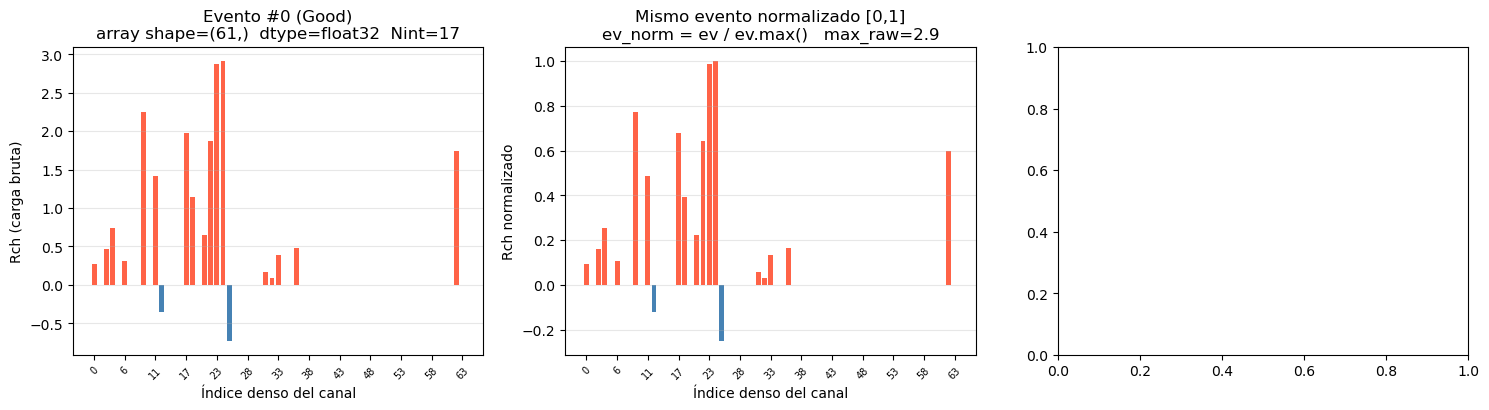

In [ ]:
w_src = widgets.ToggleButtons(options=['Good', 'Bad'],
    description='Fuente:', button_style='info')
w_idx = widgets.BoundedIntText(value=0, min=0, max=4999,
    description='Evento #:')
w_rnd = widgets.Button(description='Aleatorio', button_style='warning')
w_out = widgets.Output()

def show_event(_=None):
    with w_out:
        clear_output(wait=True)
        X  = Xg if w_src.value == 'Good' else Xb
        ev = X[w_idx.value]     # shape (61,)

        fig, axes = plt.subplots(1, 3, figsize=(18, 4))

        # --- A: array completo como barras ---
        ax = axes[0]
        colors = ['tomato' if v > 0 else 'steelblue' for v in ev]
        ax.bar(np.arange(N), ev, color=colors, width=0.8)
        ax.set_title(f'Evento #{w_idx.value} ({w_src.value})\n'
                     f'array shape={ev.shape}  dtype={ev.dtype}  '
                     f'Nint={int((ev>0).sum())}')
        ax.set_xlabel('Índice denso del canal')
        ax.set_ylabel('Rch (carga bruta)')
        ax.set_xticks(np.arange(0, N, 5))
        ax.set_xticklabels([IDX2ICH[i] for i in range(0, N, 5)],
                           fontsize=7, rotation=45)
        ax.grid(axis='y', alpha=0.3)

        # --- B: mismo array normalizado ---
        ax2 = axes[1]
        ev_norm = ev / ev.max() if ev.max() > 0 else ev
        ax2.bar(np.arange(N), ev_norm, color=colors, width=0.8)
        ax2.set_title(f'Mismo evento normalizado [0,1]\n'
                      f'ev_norm = ev / ev.max()   max_raw={ev.max():.1f}')
        ax2.set_xlabel('Índice denso del canal')
        ax2.set_ylabel('Rch normalizado')
        ax2.set_xticks(np.arange(0, N, 5))
        ax2.set_xticklabels([IDX2ICH[i] for i in range(0, N, 5)],
                            fontsize=7, rotation=45)
        ax2.grid(axis='y', alpha=0.3)

        # --- C: posición calculada ---
        ax3 = axes[2]
        rch2 = ev ** 2
        rcht = rch2.sum()
        if rcht > 0:
            pos_x = (rch2 * X_SIPM).sum() / rcht
            pos_y = (rch2 * Y_SIPM).sum() / rcht
        else:
            pos_x = pos_y = 0.0

        sz = 20 + 300 * ev_norm
        sc = ax3.scatter(X_SIPM, Y_SIPM, s=sz, c=ev, cmap='hot',
                         vmin=0, vmax=ev.max() + 1, zorder=2)
        ax3.scatter(pos_x, pos_y, s=250, marker='*',
                    color='cyan', zorder=5,
                    label=f'pos=({pos_x:.2f},{pos_y:.2f})')
        ax3.set_aspect('equal')
        ax3.set_title(f'Posición estimada\n'
                      f'X=Σ(Rch²·x)/ΣRch²   '
                      f'RchT={ev.sum():.0f}')
        ax3.legend(fontsize=8)
        ax3.grid(alpha=0.3)
        plt.colorbar(sc, ax=ax3, label='Rch')

        plt.tight_layout()
        plt.show()

        # imprimir el array numérico
        print(f'ev (raw): {np.round(ev, 1)}')
        print(f'Canales activos (Ich): '
              f'{[IDX2ICH[i] for i in np.where(ev > 0)[0]]}')

def random_ev(_=None):
    X = Xg if w_src.value == 'Good' else Xb
    w_idx.value = int(np.random.randint(0, len(X)))
    show_event()

w_idx.observe(lambda c: show_event(), names='value')
w_src.observe(lambda c: show_event(), names='value')
w_rnd.on_click(random_ev)

display(widgets.HBox([w_src, w_idx, w_rnd]), w_out)
show_event()

---
## 6 · Distribución de Nint y RchT como arrays 1D

Arrays de estadísticas por evento:
  nint_g  shape=(5000,)  min=7  max=61  mean=20.9
  rcht_g  shape=(5000,)  min=-1  max=142  mean=32



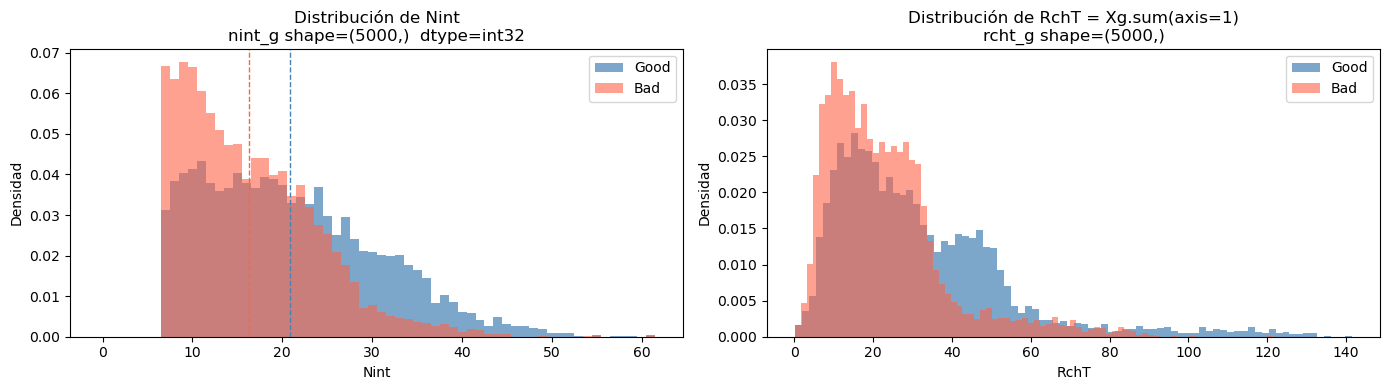

In [ ]:
# Nint como array
nint_g = np.array([ev['nint'] for ev in raw_good], dtype=np.int32)  # (5000,)
nint_b = np.array([ev['nint'] for ev in raw_bad],  dtype=np.int32)

# RchT como array
rcht_g = Xg.sum(axis=1)   # (5000,)  suma de cada fila
rcht_b = Xb.sum(axis=1)

print('Arrays de estadísticas por evento:')
print(f'  nint_g  shape={nint_g.shape}  min={nint_g.min()}  max={nint_g.max()}  mean={nint_g.mean():.1f}')
print(f'  rcht_g  shape={rcht_g.shape}  min={rcht_g.min():.0f}  max={rcht_g.max():.0f}  mean={rcht_g.mean():.0f}')
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(nint_g, bins=np.arange(0, N+2)-0.5, alpha=0.7,
             label='Good', color='steelblue', density=True)
axes[0].hist(nint_b, bins=np.arange(0, N+2)-0.5, alpha=0.6,
             label='Bad',  color='tomato',    density=True)
axes[0].set_title(f'Distribución de Nint\nnint_g shape={nint_g.shape}  dtype={nint_g.dtype}')
axes[0].set_xlabel('Nint'); axes[0].set_ylabel('Densidad')
axes[0].axvline(nint_g.mean(), color='steelblue', ls='--', lw=1)
axes[0].axvline(nint_b.mean(), color='tomato',    ls='--', lw=1)
axes[0].legend()

axes[1].hist(rcht_g[rcht_g > 0], bins=80, alpha=0.7,
             label='Good', color='steelblue', density=True)
axes[1].hist(rcht_b[rcht_b > 0], bins=80, alpha=0.6,
             label='Bad',  color='tomato',    density=True)
axes[1].set_title(f'Distribución de RchT = Xg.sum(axis=1)\nrcht_g shape={rcht_g.shape}')
axes[1].set_xlabel('RchT'); axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout(); plt.show()

---
## 7 · Matriz Good vs Bad — diferencia directa de arrays

mean_g  : shape=(61,)  dtype=float32
diff    : shape=(61,)
Canales con mayor diferencia |Good-Bad|:
  idx=59  Ich=62  Good=1.2  Bad=0.3  Δ=+0.9
  idx=33  Ich=36  Good=1.0  Bad=0.2  Δ=+0.8
  idx=10  Ich=11  Good=1.2  Bad=0.4  Δ=+0.7
  idx= 5  Ich= 6  Good=1.0  Bad=0.4  Δ=+0.6
  idx=45  Ich=48  Good=0.7  Bad=0.2  Δ=+0.5


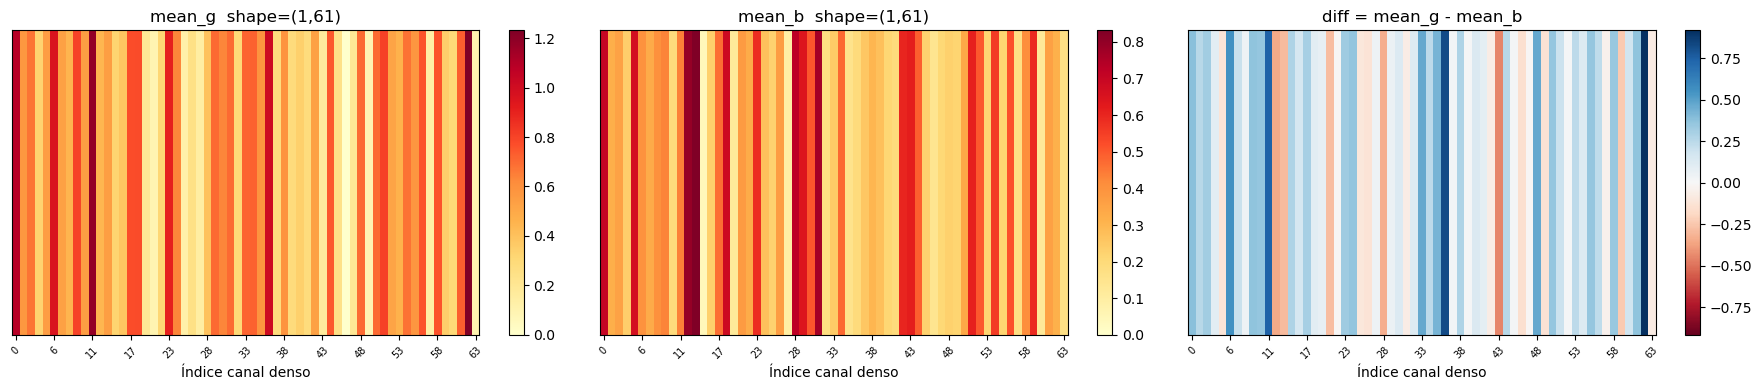

In [ ]:
# Matrices de media y std por canal
mean_g = Xg.mean(axis=0)   # (61,)
mean_b = Xb.mean(axis=0)
std_g  = Xg.std(axis=0)
std_b  = Xb.std(axis=0)
diff   = mean_g - mean_b   # (61,)  diferencia directa

print(f'mean_g  : shape={mean_g.shape}  dtype={mean_g.dtype}')
print(f'diff    : shape={diff.shape}')
print(f'Canales con mayor diferencia |Good-Bad|:')
top = np.argsort(np.abs(diff))[-5:][::-1]
for idx in top:
    print(f'  idx={idx:2d}  Ich={IDX2ICH[idx]:2d}  '
          f'Good={mean_g[idx]:.1f}  Bad={mean_b[idx]:.1f}  Δ={diff[idx]:+.1f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# heatmap mean_g  (1, 61) mostrado como imagen
for ax, arr, label, cmap in [
    (axes[0], mean_g.reshape(1, -1), 'mean_g  shape=(1,61)', 'YlOrRd'),
    (axes[1], mean_b.reshape(1, -1), 'mean_b  shape=(1,61)', 'YlOrRd'),
    (axes[2], diff.reshape(1, -1),   'diff = mean_g - mean_b', 'RdBu'),
]:
    lim = np.abs(arr).max()
    vmin = -lim if 'diff' in label else 0
    im = ax.imshow(arr, aspect='auto', cmap=cmap,
                   vmin=vmin, vmax=lim,
                   extent=[-0.5, N-0.5, -0.5, 0.5])
    ax.set_title(label)
    ax.set_xlabel('Índice canal denso')
    ax.set_yticks([])
    ax.set_xticks(np.arange(0, N, 5))
    ax.set_xticklabels([IDX2ICH[i] for i in range(0, N, 5)],
                       fontsize=7, rotation=45)
    plt.colorbar(im, ax=ax)

plt.tight_layout(); plt.show()